In [6]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import pandas as pd
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])  
import os

In [2]:
north_masks={}
south_masks={}
full_masks={}

for region in ['north', 'south', 'full']:
    if region == 'north':
        target_dict = north_masks
    elif region == 'south':
        target_dict = south_masks
    else:
        target_dict = full_masks

    for nside in [32,64,128]:
        target_dict[nside] = hp.read_map(f"imaging_systematics_maps/data/{region}_mask_nside_{nside}_for_systmatics_20M.fits")

In [3]:
randoms=fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_with_mags.fits')[1].read()
randoms =randoms[randoms['DEC']>-30]


In [4]:
for depth in ['PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R']:
    randoms['PSFMAG_' + depth[-1]]  = -2.5 * (np.log10(5.0 / np.sqrt(randoms[depth])) - 9.0)


/tmp/ipykernel_1235483/3959484691.py:2: RuntimeWarning: divide by zero encountered in divide
  randoms['PSFMAG_' + depth[-1]]  = -2.5 * (np.log10(5.0 / np.sqrt(randoms[depth])) - 9.0)


In [11]:
colspecs = [
    (0,19),   # GaiaEDR3
    (20,30),  # Gmag
    (31,41),  # BP-RP
    (42,57),  # RAdeg
    (58,73),  # DEdeg
    (74,83),  # pmRA
    (84,93),  # pmDE
    (94,99),  # e_pmRA
    (100,105),# e_pmDE
    (106,118),# DistWGBPRP
    (119,129),# e_DistWGBPRP
    (130,143),# Vlos
    (144,148),# r_Vlos
    (149,157),# [Fe/H]APOGEE
    (158,166),# [alpha/M]APOGEE
    (167,173),# [Fe/H]LAMOST
    (174,180),# [Fe/H]SEGUE
    (181,188),# SNRAPOGEE
    (189,195),# SNRgLAMOST
    (196,203),# SNRSEGUE
    (204,216),# ProbBright
    (217,229),# ProbFaint
    (230,242),# ProbSGR
    (243,255) # ProbPlx
]

names = [
    "GaiaEDR3", "Gmag", "BP_RP", "RAdeg", "DEdeg",
    "pmRA", "pmDE", "e_pmRA", "e_pmDE",
    "DistWGBPRP", "e_DistWGBPRP", "Vlos", "r_Vlos",
    "FeH_APOGEE", "AlphaM_APOGEE", "FeH_LAMOST",
    "FeH_SEGUE", "SNR_APOGEE", "SNRg_LAMOST",
    "SNR_SEGUE", "ProbBright", "ProbFaint",
    "ProbSGR", "ProbPlx"
]

df = pd.read_fwf(
    '../tablec1.dat',
    colspecs=colspecs,
    names=names,
    comment='#'
)

npix = hp.nside2npix(nside)
ra = df['RAdeg'].values
dec = df['DEdeg'].values
theta = np.radians(90.0 - dec)
phi = np.radians(ra)
pix = hp.ang2pix(nside, theta, phi, nest=False)

map = points_to_map(ra, dec, nside=128)
sigma_deg = 3.00
fwhm_deg = sigma_deg * np.sqrt(8.0 * np.log(2.0))   # ≈ 2.355 deg
fwhm_rad = np.radians(fwhm_deg)
counts_smoothed = hp.sphtfunc.smoothing(
    map,
    fwhm=fwhm_rad,
)
map  = np.where(masks_dict['full'][128]==1, counts_smoothed, hp.UNSEEN)
hp.mollview(map,cmap = 'inferno',min =0 ,max =20,rot=-85)
plt.show()

NameError: name 'masks_dict' is not defined

In [21]:
csfd_map = hp.read_map('/user/animesh.sah/csfd_maps/csfd_ebv.fits')
stellar_density_allwise = hp.read_map('/user/animesh.sah/Stellar_density/allwise_total_rot_1024.fits')
h_alpha = hp.read_map('/user/animesh.sah/Halpha_maps/Halpha_fwhm06_1024.fits')


csfd_map = np.where(np.isfinite(csfd_map), csfd_map, np.nan)

rot = hp.Rotator(coord=['G','C'])
csfd_eq = rot.rotate_map_pixel(csfd_map)
h_alpha_eq = rot.rotate_map_pixel(h_alpha)


In [22]:
##masking 

h_alpha_mask_1 = hp.read_map('/user/animesh.sah/Halpha_maps/Halpha_mask_fwhm06_1024.fits')
M = h_alpha_mask_1  # integer bitmask map

good = (
    ((M & (1<<3)) == 0)   # no STAR
    & ((M & (1<<4)) == 0) # no SATUR
    & ((M & (1<<5)) == 0) # no BRT_OBJ
    & ((M & (1<<6)) == 0) # no BIG_OBJ
    & ((M & (1<<7)) == 0) # no HI_VEL
)
h_alpha_mask  = rot.rotate_map_pixel(good.astype(float))



In [23]:
colnames = ['PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','EBV','PSFMAG_Z','PSFMAG_G','PSFMAG_R']
# Randomly sample 20M points
n_sample = min(20_000_000, len(randoms))
indices = np.random.choice(len(randoms), size=n_sample, replace=False)


ra_array_full = randoms['RA'][indices]
dec_array_full = randoms['DEC'][indices]
randoms_full = randoms[indices]

randoms_south = randoms_full[randoms_full['PHOTSYS'] == 'S']
randoms_north = randoms_full[randoms_full['PHOTSYS'] == 'N']


In [24]:
# Remove elements from randoms_full where any PSFSIZE_* column is zero
# mask_psfsize = (
#     (randoms_full['PSFSIZE_G'] != 0) &
#     (randoms_full['PSFSIZE_R'] != 0) &
#     (randoms_full['PSFSIZE_Z'] != 0)
# )
# randoms_full = randoms_full[mask_psfsize]

In [25]:
def get_mask(ra,dec,nside):
    theta = np.radians(90 -dec)
    phi = np.radians(ra)
    pix = hp.ang2pix(nside, theta, phi)
    mask = np.bincount(pix, minlength=hp.nside2npix(nside))
    mask = np.where(mask>0, 1, 0)
    return mask
def create_rand_map(part,nside):
    random_compiled = randoms_full
    rand_table=Table(random_compiled)
    rand_table = rand_table[rand_table['DEC'] > -30]

    if part == 'N':
        rand_table = rand_table[rand_table['PHOTSYS'] == 'N']
    elif part == 'S':
        rand_table = rand_table[rand_table['PHOTSYS'] == 'S']
    RA_random = np.ascontiguousarray(np.array(rand_table['RA'], dtype=np.float64))
    DEC_random= np.ascontiguousarray(np.array(rand_table['DEC'], dtype=np.float64))
    rand_map = get_mask(RA_random, DEC_random, nside)
    return rand_map

In [26]:
# north_masks={}
# south_masks={}
# full_masks={}

# for nside in [32,64,128]:
#     north_masks[nside] = create_rand_map('N',nside)
#     south_masks[nside] = create_rand_map('S',nside)
#     full_masks[nside]  = create_rand_map(None,nside)

# for masks in [north_masks, south_masks, full_masks]:
#     for nside in masks:
#         # Determine the region name based on the variable name
#         if masks is north_masks:
#             region = "north"
#         elif masks is south_masks:
#             region = "south"
#         else:
#             region = "full"
#         hp.write_map(f"{region}_mask_nside_{nside}_for_systmatics_20M.fits", masks[nside], overwrite=True)
#         print(f"Saved {region} mask with nside {nside} to {region}_mask_nside_{nside}_for_systmatics_20M.fits")

In [27]:
print("Loaded all data.")   
print(f'Number of randoms in full: {len(randoms_full):,}')
print(f'Number of randoms in north: {len(randoms_north):,}')
print(f'Number of randoms in south: {len(randoms_south):,}')

Loaded all data.
Number of randoms in full: 20,000,000
Number of randoms in north: 5,951,323
Number of randoms in south: 14,048,677


In [12]:

os.makedirs('imaging_systematics_maps', exist_ok=True)

regions = {
    'full': randoms_full,
    'north': randoms_north,
    'south': randoms_south
}

masks_dict= {
    'full': full_masks,
    'north': north_masks,
    'south': south_masks
}

NameError: name 'randoms_full' is not defined

In [9]:
def build_mean_map(ra, dec, values, nside, nest=False):
    """
    Return (mean_map, counts_map) for given arrays.
    ra, dec: degrees arrays (1D)
    values: weights or values for averaging (same length)
    nside: healpix NSIDE (nest ordering)
    """
    theta = np.radians(90.0 - dec)
    phi = np.radians(ra)
    ipix = hp.ang2pix(nside, theta, phi, nest=nest)
    npix = hp.nside2npix(nside)
    # numeric arrays
    ipix = np.asarray(ipix, dtype=np.int64)
    vals = np.asarray(values, dtype=float)

    # numerator: sum of values in pixel
    num = np.bincount(ipix, weights=vals, minlength=npix).astype(float)
    # denominator: counts (for mean)
    den = np.bincount(ipix, minlength=npix).astype(float)

    out = np.full(npix, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]

    return out, den

def psfdepth_to_m5(psfdepth):
    # psfdepth may contain zeros or negative sentinel values
    arr = np.asarray(psfdepth, dtype=float)
    out = np.full(arr.shape, 0, dtype=float)
    good = arr > 0
    out[good] = -2.5 * (np.log10(5.0 / np.sqrt(arr[good])) - 9.0)
    return out

def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [30]:
# --- Build maps for a region (single nside) ---
def build_systematics_for_region(table, colnames, mask_nside_map, external_maps_nside, nside, nest=True):
    """
    table: astropy Table or dict-like with 'RA','DEC' and feature columns
    colnames: list of columns to produce maps for (strings)
    mask_nside_map: boolean array (npix,) where True = inside footprint (for that nside)
    external_maps_nside: dict with external maps already downgraded to this nside (e.g., CSFD, stellar, halpha)
    nside: int
    returns dict: maps[name] -> array (npix,) with np.nan outside footprint
    """
    maps = {}
    ra = np.asarray(table['RA'], dtype=float)
    dec = np.asarray(table['DEC'], dtype=float)

    # counts (for valid pixel detection)
    counts_map = build_mean_map(ra, dec, np.ones_like(ra), nside, nest=nest)[1]
    valid_pixels = counts_map > 0

    for col in colnames:
        if 'PSFDEPTH' in col:
            values = psfdepth_to_m5(table[col])
        else:
            values = np.asarray(table[col], dtype=float)
        mean_map, _ = build_mean_map(ra, dec, values, nside, nest=nest)
        # mask outside footprint
        mean_map_masked = np.where(mask_nside_map, mean_map, np.nan)
        # optional: force empty pixels (counts==0) to np.nan already
        mean_map_masked[~valid_pixels] = np.nan
        maps[col] = mean_map_masked

    # attach external maps (they should be arrays at same nside, same ordering)
    for name, extmap in external_maps_nside.items():
        maps[name] = np.where(mask_nside_map, extmap, np.nan)

    # also return counts_map (masked)
    counts_map_masked = np.where(mask_nside_map, counts_map, 0)
    return maps, counts_map_masked

In [31]:
h_alpha_nside = {} 
stellar_density_allwise_nside = {}
csfd_map_nside = {}
h_alpha_mask_nside = {}
for nside in nside_values_obj :
    h_alpha_nside[nside] = hp.ud_grade(h_alpha_eq, nside_out=nside, order_in='RING', order_out='RING', power=0)
    stellar_density_allwise_nside[nside] = hp.ud_grade(stellar_density_allwise, nside_out=nside, order_in='RING', order_out='RING', power=0)
    csfd_map_nside[nside] = hp.ud_grade(csfd_eq, nside_out=nside, order_in='RING', order_out='RING', power=0)
    h_alpha_mask_nside[nside] = hp.ud_grade(h_alpha_mask, nside_out=nside, order_in='RING', order_out='RING', power=0)

NameError: name 'nside_values_obj' is not defined

In [ ]:
h_alpha_good_nside = {}
for nside in nside_values_obj:
    h_alpha_good = np.where(h_alpha_mask_nside[nside], h_alpha_nside[nside], hp.UNSEEN)
    h_alpha_good_nside[nside] = h_alpha_good


NameError: name 'nside_values_obj' is not defined

In [ ]:
ra = np.asarray(regions['full']['RA'], dtype=float)
dec = np.asarray(regions['full']['DEC'], dtype=float)
nside_val = 128
mask =masks_dict['full'][128]
maps_debug= {}
for val in ['PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z','PSFDEPTH_G','PSFDEPTH_R','PSFDEPTH_Z','EBV']: 
    if 'PSFDEPTH' in val:
        values = psfdepth_to_m5(regions['full'][val])
    else:
        values = np.asarray(regions['full'][val], dtype=float)
    pix_map, _ = build_mean_map(ra, dec, values, nside_val)
    maps_debug[val] = pix_map[mask==1]
    #pix_map = np.where(mask_nside_map, pix_map, np.nan)


In [ ]:
for band in ['PSFDEPTH_G', 'PSFDEPTH_Z', 'PSFDEPTH_R']:
    psf_depth = regions['full'][band]
    zero_mask = psf_depth == 0
    #print(f'Number of zero entries in {band}: {np.sum(zero_mask)}')
    print(f'Percentage of zero entries in {band}: {100 * np.sum(zero_mask) / len(psf_depth):.2f}%')


Percentage of zero entries in PSFDEPTH_G: 3.62%
Percentage of zero entries in PSFDEPTH_Z: 2.06%
Percentage of zero entries in PSFDEPTH_R: 3.66%


/tmp/ipykernel_1080183/2422623270.py:3: RuntimeWarning: invalid value encountered in divide
  depth_raw = np.where(counts>0, depth_raw/counts, hp.UNSEEN)


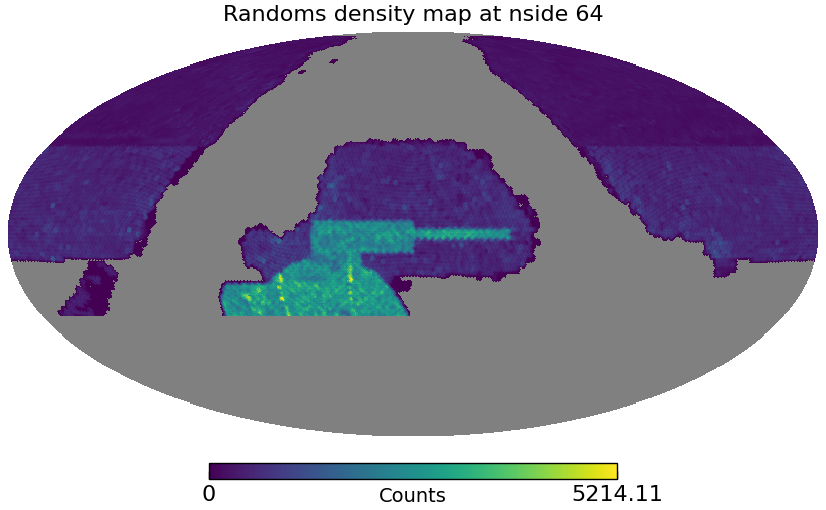

In [ ]:
depth_raw = points_to_map(regions['full']['RA'], regions['full']['DEC'], nside_val, weights=regions['full']['PSFDEPTH_R'])
counts = points_to_map(regions['full']['RA'], regions['full']['DEC'], nside_val, weights=None)
depth_raw = np.where(counts>0, depth_raw/counts, hp.UNSEEN)
hp.mollview(depth_raw, title='Randoms density map at nside 64',unit='Counts', cmap='viridis')

/tmp/ipykernel_1080183/164856702.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

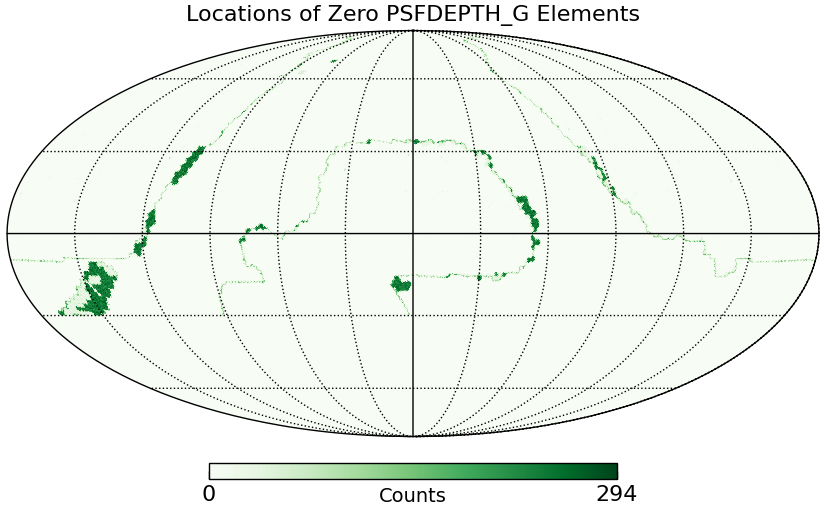

<Figure size 1000x600 with 0 Axes>

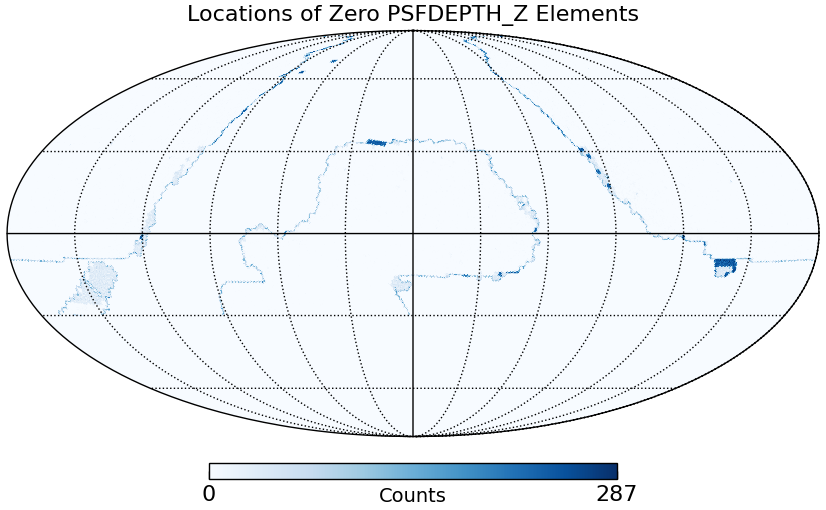

<Figure size 1000x600 with 0 Axes>

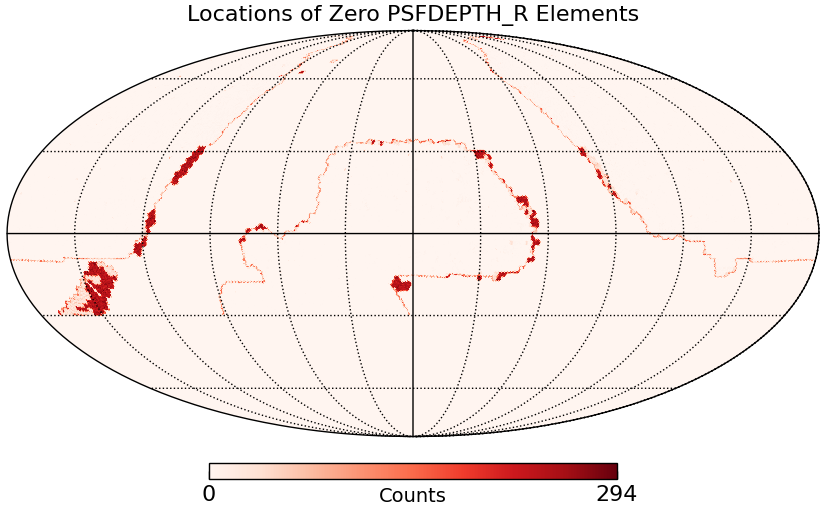

In [ ]:



# Plot locations of zero PSFDEPTH_R elements in a mollview map
import matplotlib.pyplot as plt
cmaps_ar =['Greens','Blues','Reds']
i=0
for band in ['PSFDEPTH_G', 'PSFDEPTH_Z', 'PSFDEPTH_R']:
    psf_depth = regions['full'][band]
    zero_mask = (psf_depth == 0)
    ra_zero = regions['full']['RA'][zero_mask]
    dec_zero = regions['full']['DEC'][zero_mask]

    zero_map = np.zeros(hp.nside2npix(nside_plot))
    theta_zero = np.radians(90.0 - dec_zero)
    phi_zero = np.radians(ra_zero)
    pix_zero = hp.ang2pix(nside_plot, theta_zero, phi_zero)
    np.add.at(zero_map, pix_zero, 1)

    plt.figure(figsize=(10, 6))
    hp.mollview(
        zero_map, 
        title=f'Locations of Zero {band} Elements',
        unit='Counts',
        cmap=cmaps_ar[i],  # changed color map
        min=0,
        max=np.nanmax(zero_map),
        cbar=True,
        notext=False
    )
    hp.graticule()
    plt.tight_layout()
    plt.show()
    i+=1


In [ ]:
from numpy import intersect1d

# Check if the RA/DEC locations where both PSFSIZE_R and PSFDEPTH_R are zero match
ra_both_zero = randoms_full['RA'][both_zero]
dec_both_zero = randoms_full['DEC'][both_zero]

ra_psfsize_zero = randoms_full['RA'][psfsize_zero]
dec_psfsize_zero = randoms_full['DEC'][psfsize_zero]

ra_psfdepth_zero = randoms_full['RA'][psfdepth_zero]
dec_psfdepth_zero = randoms_full['DEC'][psfdepth_zero]

print(f"Number of unique RA/DEC where both are zero: {len(ra_both_zero)}")
print(f"Number of unique RA/DEC where PSFSIZE_R is zero: {len(ra_psfsize_zero)}")
print(f"Number of unique RA/DEC where PSFDEPTH_R is zero: {len(ra_psfdepth_zero)}")

# Optionally, check overlap

ra_overlap = np.intersect1d(ra_psfsize_zero, ra_psfdepth_zero)
dec_overlap = np.intersect1d(dec_psfsize_zero, dec_psfdepth_zero)
print(f"Number of overlapping RA: {len(ra_overlap)}")
print(f"Number of overlapping DEC: {len(dec_overlap)}")


Number of unique RA/DEC where both are zero: 699170
Number of unique RA/DEC where PSFSIZE_R is zero: 699170
Number of unique RA/DEC where PSFDEPTH_R is zero: 732162
Number of overlapping RA: 699170
Number of overlapping DEC: 699170


In [ ]:
for map in maps_debug:

    print(f"{map} : {maps_debug[map].shape}")
    print(f'Number of nan elements: {np.isnan(maps_debug[map]).sum()},and Inf elements are: {np.isinf(maps_debug[map]).sum()} ')


PSFSIZE_G : (84074,)
Number of nan elements: 21,and Inf elements are: 0 
PSFSIZE_R : (84074,)
Number of nan elements: 21,and Inf elements are: 0 
PSFSIZE_Z : (84074,)
Number of nan elements: 21,and Inf elements are: 0 
PSFDEPTH_G : (84074,)
Number of nan elements: 26470,and Inf elements are: 0 
PSFDEPTH_R : (84074,)
Number of nan elements: 29965,and Inf elements are: 0 
PSFDEPTH_Z : (84074,)
Number of nan elements: 28899,and Inf elements are: 0 
EBV : (84074,)
Number of nan elements: 21,and Inf elements are: 0 


In [ ]:
maps = {}
RAW = True
for region, region_data in regions.items():
    maps[region] = {}
    for nside_val in nside_values_obj:
        maps[region][nside_val] = {}
        mask_nside_map = masks_dict[region][nside_val]
        # prepare external maps at this nside
        ra = region_data['RA']
        dec = region_data['DEC']
        print(f"\nProcessing {region} region at nside={nside_val}")
        for val in colnames: 
            if 'PSFDEPTH' in val:
                values = psfdepth_to_m5(region_data[val])
                if RAW:
                    values_raw = region_data[val]
                    pix_map_raw, _ = build_mean_map(ra, dec, values_raw, nside_val)
                    pix_map_raw = np.where(mask_nside_map, pix_map_raw, np.nan)
                    maps[region][nside_val][val + '_RAW'] = pix_map_raw
            else:
                values = np.asarray(region_data[val], dtype=float)
            pix_map, _ = build_mean_map(ra, dec, values, nside_val)
            pix_map = np.where(mask_nside_map, pix_map, np.nan)
            maps[region][nside_val][val] = pix_map

        # external maps



        # csfd_map_masked = np.where(masks_dict[region][nside_val], csfd_map_nside[nside_val], hp.UNSEEN)
        # stellar_density_allwise_masked = np.where(masks_dict[region][nside_val], stellar_density_allwise_nside[nside_val], hp.UNSEEN)
        # h_alpha_masked = np.where(masks_dict[region][nside_val], h_alpha_nside[nside_val], hp.UNSEEN)
        # h_alpha_good_masked = np.where(masks_dict[region][nside_val], h_alpha_good_nside[nside_val], hp.UNSEEN)
        # maps[region][nside_val]['CSFD'] = csfd_map_masked
        # maps[region][nside_val]['Stellar_Density_AllWISE'] = stellar_density_allwise_masked
        # maps[region][nside_val]['H_Alpha'] = h_alpha_masked
        # maps[region][nside_val]['H_Alpha_Good'] = h_alpha_good_masked


            

        

NameError: name 'nside_values_obj' is not defined

In [ ]:

values = psfdepth_to_m5(regions['full']['PSFDEPTH_Z'])
ra = np.asarray(regions['full']['RA'], dtype=float)
dec = np.asarray(regions['full']['DEC'], dtype=float)

map_depth_z =  build_mean_map(ra, dec, values,64)

In [ ]:
theta = np.radians(90.0 - dec)
phi   = np.radians(ra)
pix  = hp.ang2pix(64, theta, phi, nest=False)
npix  = hp.nside2npix(64)
depth_map = np.bincount(pix, weights=values, minlength=npix).astype(float)
counts_map = np.bincount(pix, minlength=npix).astype(float)
mean_depth_map = np.full(npix, np.nan, dtype=float)
mask = counts_map > 0
mean_depth_map[mask] = depth_map[mask] / counts_map[mask]

In [ ]:
np.min(values),np.max(values)

(nan, nan)

In [ ]:
import matplotlib.pyplot as plt

nan_mask = np.isnan(values)
nan_map = np.zeros_like(mean_depth_map)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 49152 but corresponding boolean dimension is 20000000

(array([2.000000e+00, 2.000000e+00, 0.000000e+00, 7.000000e+00,
        4.000000e+00, 4.000000e+00, 5.000000e+00, 1.600000e+01,
        1.000000e+00, 0.000000e+00, 1.000000e+00, 0.000000e+00,
        2.000000e+00, 4.000000e+00, 0.000000e+00, 1.000000e+00,
        3.000000e+00, 0.000000e+00, 3.000000e+00, 9.290000e+02,
        5.310000e+02, 2.590000e+02, 7.300000e+01, 3.740000e+02,
        1.652000e+03, 5.350000e+02, 9.800000e+01, 2.880000e+02,
        8.740000e+02, 2.256000e+03, 1.013000e+03, 2.330000e+03,
        4.688000e+03, 4.868000e+03, 3.269000e+03, 4.526000e+03,
        5.478000e+03, 4.232000e+03, 6.109000e+03, 7.575000e+03,
        4.315000e+03, 5.808000e+03, 5.744000e+03, 7.353000e+03,
        9.376000e+03, 1.274400e+04, 1.748100e+04, 2.858900e+04,
        3.735800e+04, 4.636600e+04, 5.098600e+04, 5.806900e+04,
        6.445800e+04, 7.806000e+04, 8.732800e+04, 9.344800e+04,
        1.061160e+05, 1.330950e+05, 1.629900e+05, 2.061320e+05,
        2.505940e+05, 3.101320e+05, 3.87

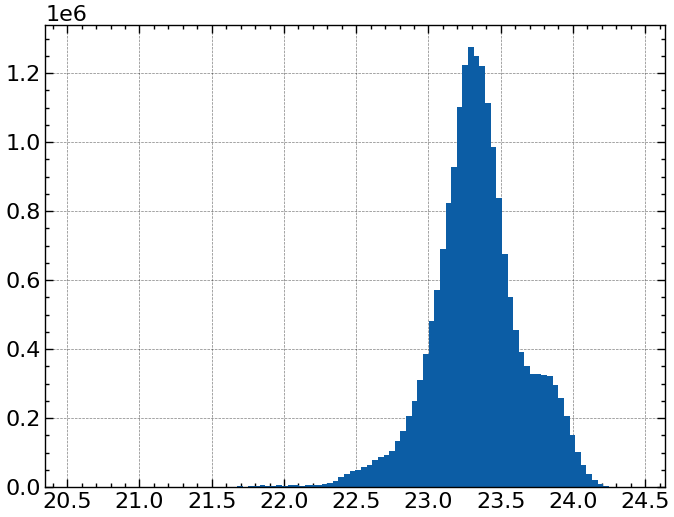

In [ ]:
plt.hist(values, bins=100)

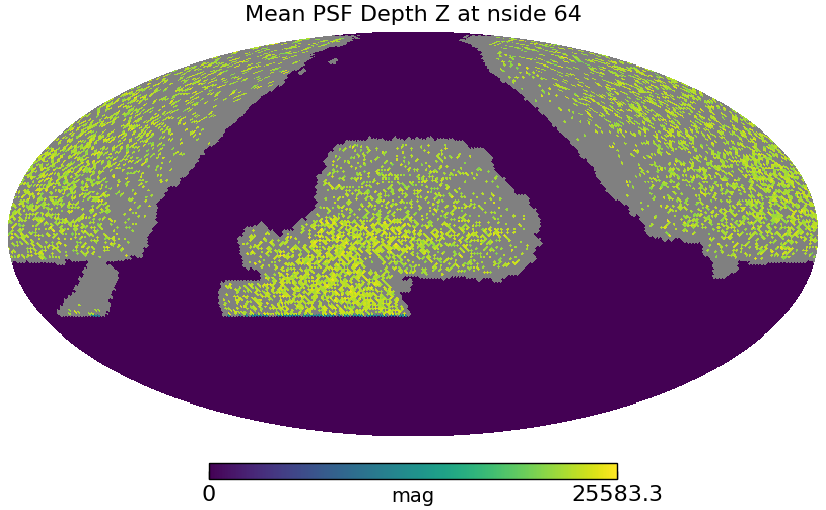

In [ ]:
hp.mollview(depth_map, title='Mean PSF Depth Z at nside 64',unit='mag', cmap='viridis')

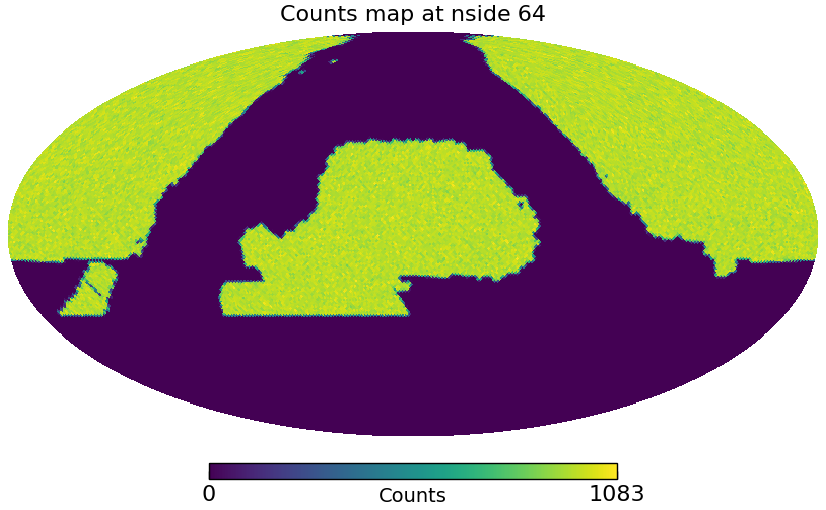

In [ ]:
hp.mollview(counts_map, title='Counts map at nside 64',unit='Counts', cmap='viridis')

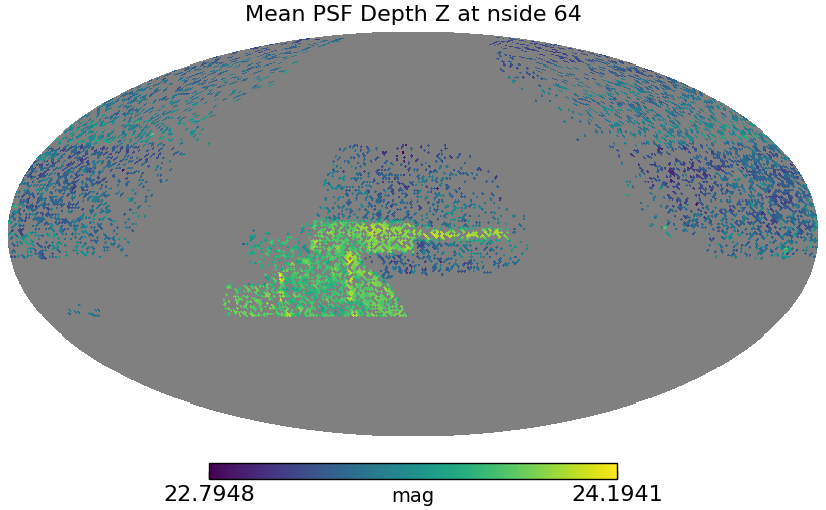

In [ ]:
hp.mollview(mean_depth_map, title='Mean PSF Depth Z at nside 64',unit='mag', cmap='viridis')

In [ ]:
len(values)

20000000

In [ ]:
np.isnan(values).sum()


411060

In [ ]:
(411060/20000000)*100

2.0553

In [ ]:
def build_mean_map(ra, dec, values, nside, nest=False):
    """
    Return (mean_map, counts_map) for given arrays.
    ra, dec: degrees arrays (1D)
    values: weights or values for averaging (same length)
    nside: healpix NSIDE (nest ordering)
    """
    theta = np.radians(90.0 - dec)
    phi = np.radians(ra)
    ipix = hp.ang2pix(nside, theta, phi, nest=nest)
    npix = hp.nside2npix(nside)
    # numeric arrays
    ipix = np.asarray(ipix, dtype=np.int64)
    vals = np.asarray(values, dtype=float)

    # numerator: sum of values in pixel
    num = np.bincount(ipix, weights=vals, minlength=npix).astype(float)
    # denominator: counts (for mean)
    den = np.bincount(ipix, minlength=npix).astype(float)

    out = np.full(npix, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]

    return out, den

def psfdepth_to_m5(psfdepth):
    # psfdepth may contain zeros or negative sentinel values
    arr = np.asarray(psfdepth, dtype=float)
    out = np.full(arr.shape, np.nan, dtype=float)
    good = arr > 0
    out[good] = -2.5 * (np.log10(5.0 / np.sqrt(arr[good])) - 9.0)
    return out

array([0.05434595, 0.05880095, 0.10889415, ..., 0.0676148 , 0.06813378,
       0.06211327])

In [ ]:
ebv  = maps['full'][64]['EBV'][masks_dict['full'][64]==1]
print(ebv[ebv<0])
print()

[]


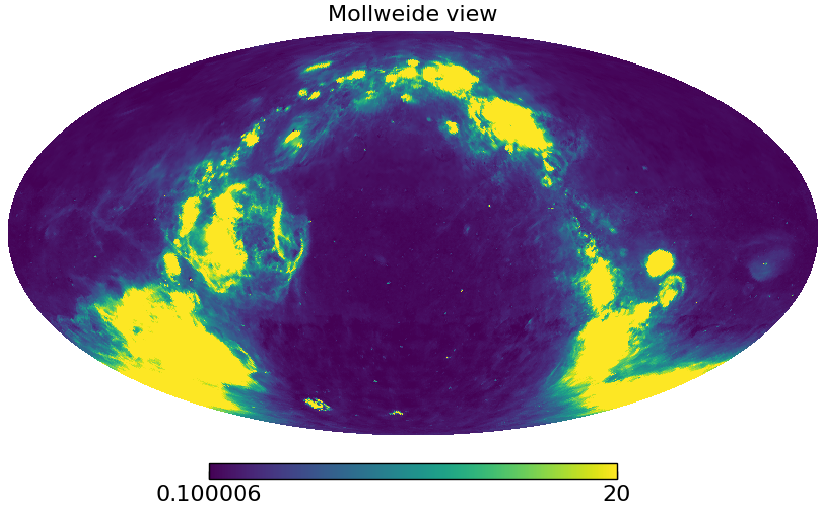

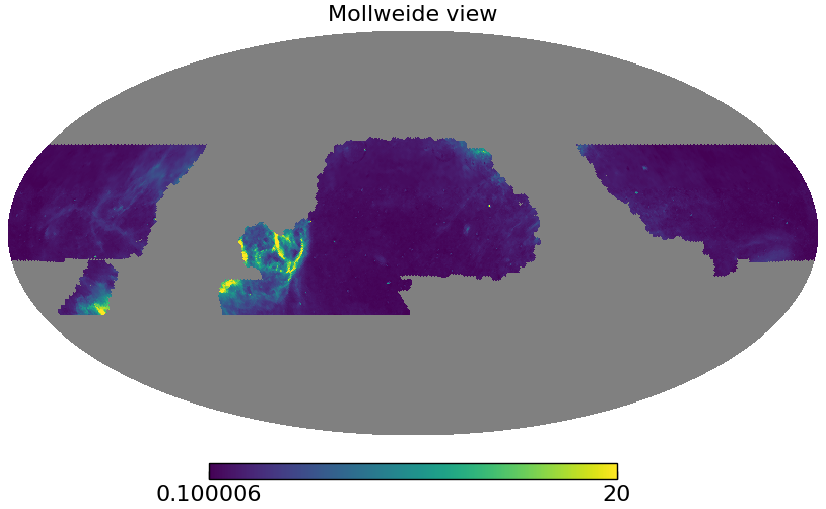

In [ ]:
hp.mollview(h_alpha_nside[nside_val],max = 20)
hp.mollview(h_alpha_masked,max =20 )

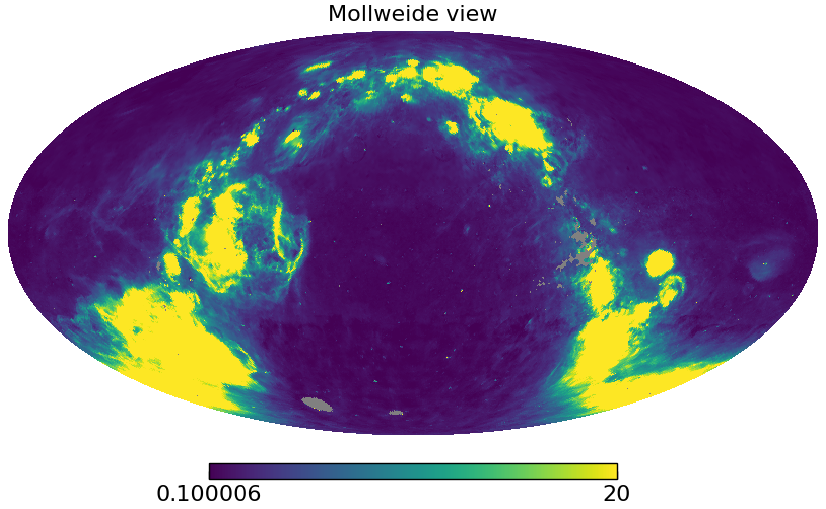

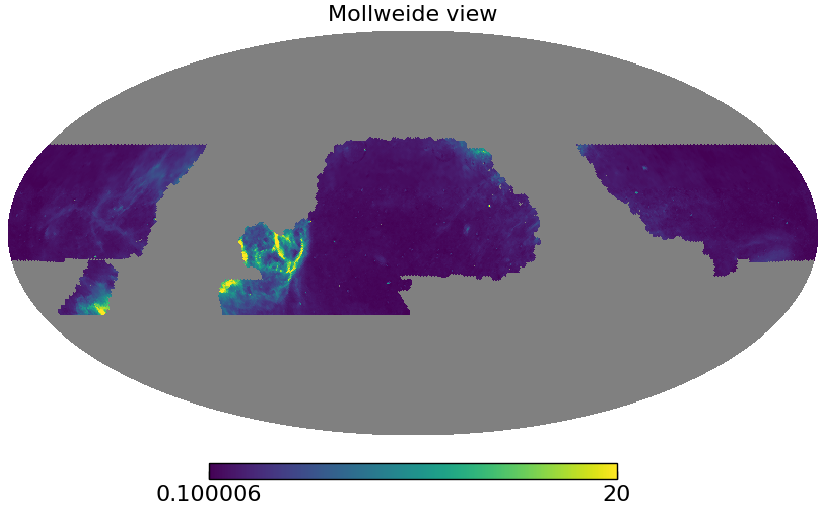

In [ ]:
hp.mollview(h_alpha_good_nside[nside_val],max =20 )
hp.mollview(h_alpha_good_masked,max =20  )

In [ ]:
counts_randoms = {}
for region in regions.keys():
    dat = regions[region]
    counts_randoms[region] = {}
    for nside in nside_values_obj:
        mask = masks_dict[region][nside]
        counts_randoms[region][nside] = points_to_map(dat['RA'], dat['DEC'], nside=nside)

In [ ]:
##Save all maps and counts_randoms
# for region in regions.keys():
#     for nside in nside_values_obj:
#         # Save each systematic map
#         for map_name, map_data in maps[region][nside].items():
#             filename = f"imaging_systematics_maps/data/{region}_{map_name}_nside_{nside}.fits"
#             hp.write_map(filename, map_data, overwrite=True)
#             print(f"Saved {filename}")
        
#         # Save counts_randoms map
#         counts_filename = f"imaging_systematics_maps/data/{region}_counts_randoms_nside_{nside}.fits"
#         hp.write_map(counts_filename, counts_randoms[region][nside], overwrite=True)
#         print(f"Saved {counts_filename}")

# print("\nAll maps and counts saved successfully!")

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to

Saved imaging_systematics_maps/data/full_PSFDEPTH_Z_RAW_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_Z_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_G_RAW_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_G_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_R_RAW_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_R_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFSIZE_G_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFSIZE_R_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFSIZE_Z_nside_32.fits
Saved imaging_systematics_maps/data/full_EBV_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFMAG_Z_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFMAG_G_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFMAG_R_nside_32.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_Z_RAW_nside_64.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_Z_nside_64.fits
Saved imag

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to

Saved imaging_systematics_maps/data/full_PSFDEPTH_G_RAW_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_G_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_R_RAW_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFDEPTH_R_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFSIZE_G_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFSIZE_R_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFSIZE_Z_nside_128.fits
Saved imaging_systematics_maps/data/full_EBV_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFMAG_Z_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFMAG_G_nside_128.fits
Saved imaging_systematics_maps/data/full_PSFMAG_R_nside_128.fits
Saved imaging_systematics_maps/data/north_PSFDEPTH_Z_RAW_nside_32.fits
Saved imaging_systematics_maps/data/north_PSFDEPTH_Z_nside_32.fits
Saved imaging_systematics_maps/data/north_PSFDEPTH_G_RAW_nside_32.fits
Saved imaging_systematics_maps/data/north_PSFDEPTH_G_nside_32.

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to

Saved imaging_systematics_maps/data/north_PSFMAG_R_nside_128.fits
Saved imaging_systematics_maps/data/south_PSFDEPTH_Z_RAW_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFDEPTH_Z_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFDEPTH_G_RAW_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFDEPTH_G_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFDEPTH_R_RAW_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFDEPTH_R_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFSIZE_G_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFSIZE_R_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFSIZE_Z_nside_32.fits
Saved imaging_systematics_maps/data/south_EBV_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFMAG_Z_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFMAG_G_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFMAG_R_nside_32.fits
Saved imaging_systematics_maps/data/south_PSFDEPTH_Z_RAW_nside_64.f

In [ ]:
counts = {}

data={}
data['full'] = Table(fitsio.FITS('../table_match_final.fits')[1].read())
data['north'] = Table(fitsio.FITS(f'../../FP_CUTS/table_north_unique.fits')[1].read())
data['north']= data['north'][data['north']['DEC']>10]

data['south'] = Table(fitsio.FITS(f'../../FP_CUTS/table_south_unique.fits')[1].read())
for region in data.keys():
    dat = data[region]
    counts[region] = {}
    for nside in nside_values_obj:
        mask = masks_dict[region][nside]
        counts[region][nside] = points_to_map(dat['RA'], dat['DEC'], nside=nside)

In [ ]:
# List all the systematic map names
systematics_names = list(maps['full'][32].keys())
print("Systematic maps available:")
for i, name in enumerate(systematics_names, 1):
    print(f"{i}. {name}")

Systematic maps available:
1. PSFDEPTH_Z_RAW
2. PSFDEPTH_Z
3. PSFDEPTH_G_RAW
4. PSFDEPTH_G
5. PSFDEPTH_R_RAW
6. PSFDEPTH_R
7. PSFSIZE_G
8. PSFSIZE_R
9. PSFSIZE_Z
10. EBV
11. PSFMAG_Z
12. PSFMAG_G
13. PSFMAG_R
